In [2]:
#import data
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

#uploading csv data - readmissions from CMS
from google.colab import drive
drive.mount ('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/CMSdata.csv")
df.head()

Mounted at /content/drive


,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


In [3]:
import pandas as pd

#preview data
print ("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (18330, 12)

Columns: ['Facility Name', 'Facility ID', 'State', 'Measure Name', 'Number of Discharges', 'Footnote', 'Excess Readmission Ratio', 'Predicted Readmission Rate', 'Expected Readmission Rate', 'Number of Readmissions', 'Start Date', 'End Date']


,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


In [4]:
conn = sqlite3.connect("readmissions.db")

In [5]:
df.to_sql("readmissions", conn, if_exists="replace", index=False)

18330

In [6]:
query = """
SELECT
`Measure Name`,
COUNT(*) as total_hospitals,
ROUND(AVG(CAST(`Excess Readmission Ratio` AS FLOAT)),3) AS avg_excess_ratio
FROM readmissions
WHERE `Excess Readmission Ratio` != 'Not Available'
GROUP BY `Measure Name`
ORDER BY avg_excess_ratio DESC
"""

results = pd.read_sql_query(query, conn)
print (results)


             Measure Name  total_hospitals  avg_excess_ratio
0  READM-30-HIP-KNEE-HRRP             1447             1.004
1      READM-30-CABG-HRRP              878             1.002
2       READM-30-AMI-HRRP             1736             1.002
3        READM-30-PN-HRRP             2715             1.001
4        READM-30-HF-HRRP             2621             1.001
5      READM-30-COPD-HRRP             2323             1.001


In [7]:
# readmission rates by state
query2 = """
SELECT
  State,
  COUNT (DISTINCT `Facility ID`) as total_hospitals,
  ROUND (AVG(CAST(`Excess Readmission Ratio` AS FLOAT)), 4) as avg_excess_ratio,
  ROUND(MIN(CAST(`Excess Readmission Ratio` AS FLOAT)), 4) as best_ratio,
  ROUND(MAX(CAST(`Excess Readmission Ratio` AS FLOAT)), 4) as worst_ratio
 FROM readmissions
 WHERE `Excess Readmission Ratio` != 'Not Available'
 GROUP BY state
 ORDER BY avg_excess_ratio DESC
 LIMIT 15
 """
state_results = pd.read_sql_query(query2, conn)
print (state_results)

   State  total_hospitals  avg_excess_ratio  best_ratio  worst_ratio
0     MA               52            1.0344      0.5939       1.5658
1     NJ               61            1.0277      0.6856       1.4237
2     FL              164            1.0229      0.7434       1.5196
3     IL              109            1.0194      0.8297       1.5827
4     MS               50            1.0141      0.7606       1.3049
5     AL               67            1.0139      0.8186       1.3851
6     WV               22            1.0115      0.7825       1.3033
7     NV               19            1.0114      0.7934       1.2523
8     GA               88            1.0114      0.8445       1.5095
9     KY               59            1.0101      0.7915       1.3861
10    CA              253            1.0101      0.4698       1.4839
11    OH              111            1.0085      0.7526       1.6297
12    LA               67            1.0080      0.7594       1.3037
13    PA              126         

In [8]:
#determing worst performing individual hospitals
query3 = """
SELECT
`Facility Name` , State, `Measure Name`,
ROUND(MAX(CAST(`Excess Readmission Ratio` AS FLOAT)), 4) as worst_ratio
FROM readmissions
WHERE `Excess Readmission Ratio` != 'Not Available'
GROUP BY `Facility Name`, `Measure Name`
ORDER BY worst_ratio DESC
LIMIT 15
"""
outlier_results = pd.read_sql_query(query3, conn)
print (outlier_results)

                              Facility Name State            Measure Name  \
0                  FAIRFIELD MEDICAL CENTER    OH  READM-30-HIP-KNEE-HRRP   
1              CARLE BROMENN MEDICAL CENTER    IL  READM-30-HIP-KNEE-HRRP   
2                      HOLY FAMILY HOSPITAL    MA  READM-30-HIP-KNEE-HRRP   
3   BROWN UNIVERSITY HEALTH MORTON HOSPITAL    MA  READM-30-HIP-KNEE-HRRP   
4      GREAT PLAINS REGIONAL MEDICAL CENTER    OK  READM-30-HIP-KNEE-HRRP   
5           SAINT FRANCIS HOSPITAL MUSKOGEE    OK  READM-30-HIP-KNEE-HRRP   
6             HCA FLORIDA OAK HILL HOSPITAL    FL  READM-30-HIP-KNEE-HRRP   
7                        ST MARY'S HOSPITAL    GA  READM-30-HIP-KNEE-HRRP   
8             GOOD SAMARITAN MEDICAL CENTER    FL  READM-30-HIP-KNEE-HRRP   
9                 ECU HEALTH MEDICAL CENTER    NC  READM-30-HIP-KNEE-HRRP   
10                UCI HEALTH - LOS ALAMITOS    CA  READM-30-HIP-KNEE-HRRP   
11                         UPMC ST MARGARET    PA  READM-30-HIP-KNEE-HRRP   

In [9]:
query4 = """
SELECT
`Facility Name`, State, `Measure Name`,
CAST(`Excess Readmission Ratio` AS FLOAT) AS excess_ratio,
CAST (`Number of Discharges` AS INT) AS discharges,
CAST (`Number of Readmissions` AS INT) AS readmissions
FROM readmissions
WHERE `Excess Readmission Ratio` != 'Not Available'
AND `Number of Discharges` != 'Not Available'
AND `Number of Readmissions` != 'Not Available'
"""
df_clean= pd.read_sql_query(query4, conn)
print(f"Clean dataset shape: {df_clean.shape}")
print(f"\nNull values: \n{df_clean.isnull().sum()}")
df_clean.head()


Clean dataset shape: (8037, 6)

Null values: 
Facility Name    0
State            0
Measure Name     0
excess_ratio     0
discharges       0
readmissions     0
dtype: int64


,Facility Name,State,Measure Name,excess_ratio,discharges,readmissions
0,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-CABG-HRRP,0.9531,137,13
1,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-AMI-HRRP,0.9370,273,33
2,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-COPD-HRRP,0.9823,122,19
3,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-PN-HRRP,0.9871,507,79
4,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-HF-HRRP,1.0233,653,136


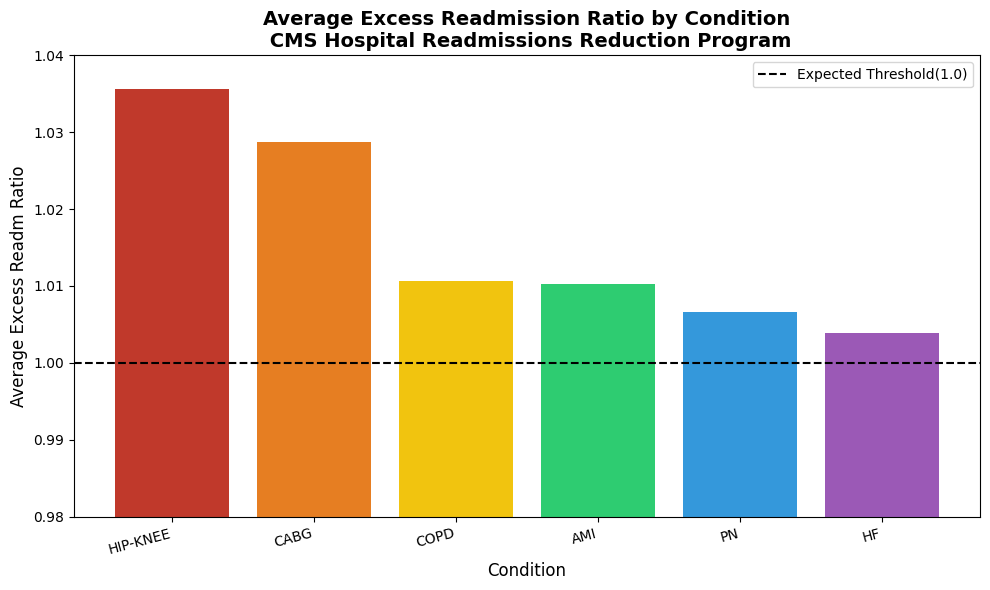

Chart Saved!


In [10]:
import matplotlib.pyplot as plt
# building visualization of average excess ratio
condition_avg = df_clean.groupby("Measure Name")["excess_ratio"].mean().sort_values(ascending=False)

# names to display
condition_avg.index = condition_avg.index.str.replace("READM-30-","").str.replace("-HRRP","")

#creating dimensions and details of chart
plt.figure(figsize=(10,6))
bars = plt.bar(condition_avg.index, condition_avg.values, color =["#c0392b", "#e67e22", "#f1c40f", "#2ecc71", "#3498db", "#9b59b6"])
plt.axhline(y= 1.0, color = "black", linestyle = "--", linewidth = 1.5, label= "Expected Threshold(1.0)")
plt.title("Average Excess Readmission Ratio by Condition\n CMS Hospital Readmissions Reduction Program", fontsize= 14, fontweight = "bold")
plt.xlabel("Condition", fontsize = 12)
plt.ylabel("Average Excess Readm Ratio", fontsize= 12)
plt.xticks(rotation = 15, ha = "right")
plt.ylim(0.98, 1.04)
plt.legend()
plt.tight_layout()
plt.savefig("readmissions by condition.png", dpi= 150)
plt.show()
print("Chart Saved!")

In [11]:
#calculating penalty risk score
df_clean["penalty risk score"]=((df_clean["excess_ratio"] -1) *df_clean["discharges"]).round(2)

#threshold calculation for high risk hospitals
df_clean["high_risk"] = df_clean["penalty risk score"] > df_clean["penalty risk score"].quantile(0.75)

#print top 15 hospitals at highest risk
top_risk = df_clean[df_clean["excess_ratio"] > 1.0]\
.groupby(["Facility Name", "State"])[["penalty risk score"]]\
.sum()\
.sort_values(by="penalty risk score", ascending=False)\
.reset_index()\
.head(15)

print("Top 15 Highest Penalty Risk Hospitals:\n")
print(top_risk.to_string(index=False))

Top 15 Highest Penalty Risk Hospitals:

                  Facility Name State  penalty risk score
           ADVENTHEALTH ORLANDO    FL             1351.79
        BAYSTATE MEDICAL CENTER    MA              563.62
         LEHIGH VALLEY HOSPITAL    PA              562.57
       COMMUNITY MEDICAL CENTER    NJ              534.01
           SOUTH SHORE HOSPITAL    MA              516.09
              OROVILLE HOSPITAL    CA              486.97
        ST LUCIE MEDICAL CENTER    FL              479.89
      MAIMONIDES MEDICAL CENTER    NY              463.73
           WEST JERSEY HOSPITAL    NJ              463.05
       MARY WASHINGTON HOSPITAL    VA              454.92
            WINCHESTER HOSPITAL    MA              442.53
      MARION COMMUNTIY HOSPITAL    FL              396.41
   JEFFERSON STRATFORD HOSPITAL    NJ              390.08
              CAPE COD HOSPITAL    MA              365.07
MILFORD REGIONAL MEDICAL CENTER    MA              364.35


In [13]:
#exporting 2 datasets to build tableau visualiations

state_export = df_clean.groupby("State").agg(
    total_hospitals = ("Facility Name", "nunique"),
    avg_excess_ratio = ("excess_ratio", "mean"),
    total_readmissions = ("readmissions", "sum"),
    total_discharges = ("discharges", "sum"),
    avg_penalty_risk = ("penalty risk score", "mean")
).round(4).reset_index()

#hospital export
hospital_export = df_clean.groupby(["Facility Name", "State"]).agg(
    avg_excess_ratio = ("excess_ratio", "mean"),
    total_readmissions = ("readmissions", "sum"),
    total_discharges = ("discharges", "sum"),
    total_pentalty_risk = ("penalty risk score", "sum"),
    high_risk = ("high_risk", "sum")
).round(4).reset_index()

state_export.to_csv("/content/drive/MyDrive/state_readmissions.csv", index = False)
hospital_export.to_csv("/content/drive/MyDrive/hospital_readmissions.csv", index = False)

print (f"State File Exported: {state_export.shape}")
print (f"Hospital File Exported: {hospital_export.shape}")
print(f"\nState file preview:")
print(state_export.sort_values("avg_excess_ratio", ascending=False).head())


State File Exported: (51, 6)
Hospital File Exported: (2476, 7)

State file preview:
   State  total_hospitals  avg_excess_ratio  total_readmissions  \
19    MA               52            1.0444               15668   
31    NJ               61            1.0310               15078   
9     FL              159            1.0280               35222   
25    MS               43            1.0268                5121   
14    IL              103            1.0265               20558   

    total_discharges  avg_penalty_risk  
19             92376           12.6469  
31             83063            8.7426  
9             197109            8.3096  
25             29154            7.6407  
14            116336            6.9234  
